# Flujo Completo del Challenge — Segmentación de Sellers de Mercado Libre (MLM)

**Caso de negocio:** el equipo comercial quiere estrategias focalizadas por seller, pero hoy no existe una clasificación de vendedores por su comportamiento. Construimos una **segmentación no supervisada** sobre un snapshot de 185.250 publicaciones (2024-08-01) consolidadas en 46.524 vendedores.

Este notebook recorre la historia completa: **dato → calidad → limpieza → features → 3 iteraciones del clustering → modelo final → segmentos → estrategia → GenAI → escalabilidad**.

> Detalle metodológico: [`INFORME_TECNICO.md`](INFORME_TECNICO.md) · Reporte visual: `report_mlm.html`

In [1]:
import json
import pandas as pd

from config import LOG_CLUSTER_FEATURES, PRICE_ERROR_THRESHOLD_MXN
from data_loading import load_dataset, get_dataset_overview, get_seller_grain_checks
from data_quality import (
    run_quality_audit, get_outlier_summary,
    filter_critical_errors, drop_absolute_price_outliers, impute_price_by_category,
)
from feature_engineering import build_seller_features, add_log_features
from clustering import evaluate_kmeans_range, fit_final_kmeans, summarize_clusters
from visualization import (
    set_plot_style, plot_numeric_distribution, plot_top_categories, plot_cluster_feature_means,
)

set_plot_style()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 150)
print("Módulos cargados.")

Módulos cargados.


## 1. Carga y grano del dato (ítem → seller)

El dataset está a nivel **ítem** (publicación), no vendedor. Para clusterizar sellers hay que consolidar el grano.

In [2]:
df = load_dataset("df_challenge_meli.csv")
overview = get_dataset_overview(df)
grain = get_seller_grain_checks(df)

print(f"Filas (ítems):       {overview['rows']:,}")
print(f"Vendedores únicos:   {overview['distinct_sellers']:,}")
print(f"Snapshot:            {overview.get('min_tim_day')}  →  {overview.get('max_tim_day')}")
print(f"\nGrano ítem (no seller):")
print(f"  Ítems por seller — promedio: {grain['avg_rows_per_seller']}  |  máximo: {grain['max_rows_per_seller']:,}")
print(f"  Sellers con 1 solo ítem:     {grain['sellers_with_one_row']:,}")

Filas (ítems):       185,250
Vendedores únicos:   46,586
Snapshot:            2024-08-01 00:00:00  →  2024-08-01 00:00:00

Grano ítem (no seller):
  Ítems por seller — promedio: 3.98  |  máximo: 1,421
  Sellers con 1 solo ítem:     24,517


**Hallazgo logístico:** MLM tiene 5 canales. XD domina (63%) y **DS (Drop Shipping) es 13,3%** — define un segmento propio.

In [3]:
canales = (df['logistic_type'].fillna('Otro').value_counts(dropna=False)
           .rename_axis('canal').reset_index(name='registros'))
canales['pct'] = (canales['registros'] / len(df) * 100).round(2)
canales

,canal,registros,pct
0,XD,116763,63.03
1,FBM,31483,16.99
2,DS,24645,13.30
3,Otro,10541,5.69
4,FLEX,1818,0.98


## 2. Data Quality Audit

Auditoría **pasiva**: medir, clasificar y tratar — sin descartar más de lo estrictamente necesario.

In [4]:
audit = run_quality_audit(df)
display(audit)

outliers = get_outlier_summary(df)
print('\nResumen de outliers (p99):')
for _, r in outliers.iterrows():
    print(f"  {r['column']:>14}  max=${r['max']:,.0f}   p99=${r['threshold']:,.0f}")
print(f"\n⚠️  Precio máximo = ${df['price'].max():,.0f} MXN → error de carga evidente.")

,problema,registros_afectados,porcentaje,tipo,tratamiento_sugerido
6,regular_price nulo,135294,73.03,comportamiento_esperado,Interpretar como item sin precio regular/promo...
3,seller_reputation nula,2372,1.28,posible_comportamiento_esperado,Mantener como categoria 'sin_reputacion' y med...
4,price nulo,1516,0.82,error,Excluir de features de precio o imputar solo c...
10,condition not_specified,83,0.04,comportamiento_esperado,Mantener como categoria propia y monitorear pr...
5,price menor o igual a cero,2,0.00,posible_error,Flaggear y excluir de estadisticas de precio s...
0,Filas duplicadas exactas,0,0.00,posible_error,Eliminar duplicados exactos antes de construir...
11,categoria distinta de category_id,0,0.00,posible_inconsistencia,Validar diccionario de categorias antes de ele...
7,regular_price menor que price,0,0.00,posible_error,No calcular descuento para estos casos; revisa...
1,seller_nickname nulo,0,0.00,error,Descartar o enviar a reproceso; no permite agr...
8,stock negativo,0,0.00,error,Convertir a nulo o descartar; stock negativo n...



Resumen de outliers (p99):
           stock  max=$99,999   p99=$5,000
           price  max=$4,772,353,854   p99=$29,999
   regular_price  max=$999,999   p99=$19,473

⚠️  Precio máximo = $4,772,353,854 MXN → error de carga evidente.


**Umbral correcto:** `p99 = $29.999 MXN` es demasiado agresivo (elimina electrónica premium legítima). Usamos `$1.000.000 MXN` como umbral de dominio (`PRICE_ERROR_THRESHOLD_MXN`).

## 3. Limpieza — el orden importa

`limpiar errores → quitar > $1M → imputar por categoría`

Limpiar **antes** de imputar evita que errores de carga contaminen la mediana de la categoría (este era el bug de la iteración 2 del clustering).

In [5]:
df_clean, df_err   = filter_critical_errors(df)
df_no_out, df_out  = drop_absolute_price_outliers(df_clean, PRICE_ERROR_THRESHOLD_MXN)
df_final           = impute_price_by_category(df_no_out)

print(f"Original:             {len(df):>8,} ítems")
print(f"- Errores críticos:   {len(df_err):>8,}")
print(f"- Precio > $1M MXN:   {len(df_out):>8,}")
print(f"= Dataset limpio:     {len(df_final):>8,} ítems")
print(f"\nPrecio máximo limpio: ${df_final['price'].max():,.0f}")

Original:              185,250 ítems
- Errores críticos:          2
- Precio > $1M MXN:         77
= Dataset limpio:      185,171 ítems

Precio máximo limpio: $1,000,000


## 4. Feature engineering (ítem → seller)

El perfil de un seller no está en *qué* vende sino en *cómo* opera. Tres decisiones clave:

1. **Reputación nula → `fillna(4)` + `has_reputation`** — no confundir nuevo con penalizado.
2. **`pct_ds` y `pct_flex`** — agregados a las proporciones logísticas.
3. **`log1p`** — comprime la cola larga de precios y volumen.

In [6]:
sf = build_seller_features(df_final)
sf = add_log_features(sf)

print(f"Vendedores: {len(sf):,}  |  Features: {sf.shape[1]}\n")
for k, v in {
    'pct_ds presente': 'pct_ds' in sf.columns,
    'log_avg_price presente': 'log_avg_price' in sf.columns,
    'has_reputation presente': 'has_reputation' in sf.columns,
    'reputation_score >= 1 (sin fillna 0)': bool(sf['seller_reputation_score'].min() >= 1),
}.items():
    print(f"  {'✓' if v else '✗'} {k}")

sf[['seller_nickname','items_count','median_price','pct_fbm','pct_xd','pct_ds',
    'seller_reputation_score','has_reputation']].head()

Vendedores: 46,524  |  Features: 34

  ✓ pct_ds presente
  ✓ log_avg_price presente
  ✓ has_reputation presente
  ✓ reputation_score >= 1 (sin fillna 0)


,seller_nickname,items_count,median_price,pct_fbm,pct_xd,pct_ds,seller_reputation_score,has_reputation
0,000631669c,1,799.0,0.0,0.0,0.0,4.0,1
1,0007153bca,2,399.0,0.0,1.0,0.0,6.0,1
2,000bee3c3b,2,382.5,0.0,1.0,0.0,4.0,1
3,000df2bd02,1,1550.0,0.0,1.0,0.0,6.0,1
4,000e27cea2,2,457.5,0.5,0.5,0.0,7.0,1


## 5. EDA visual

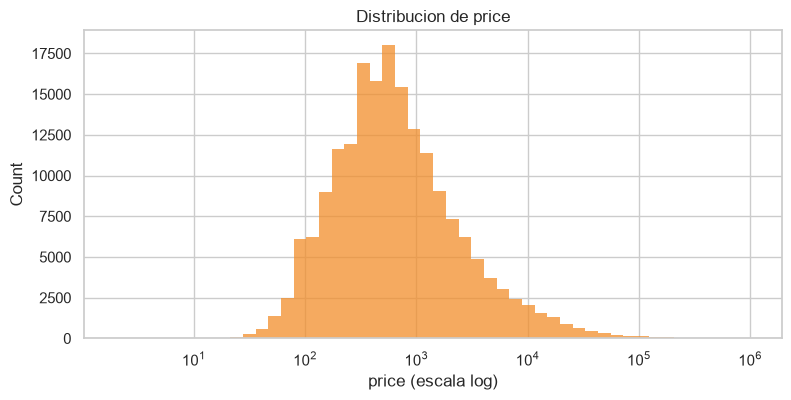

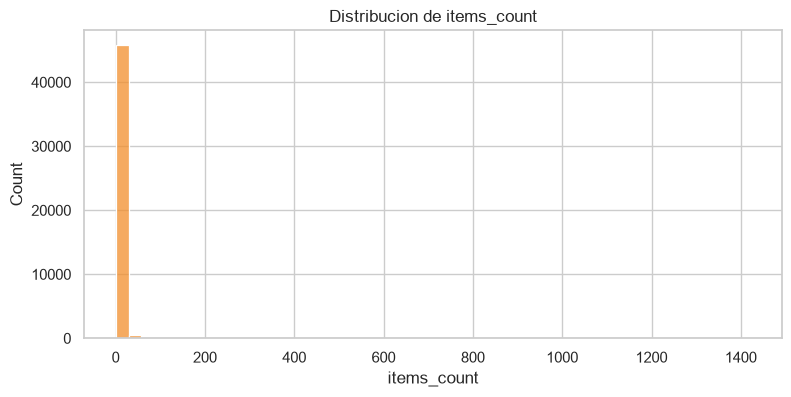

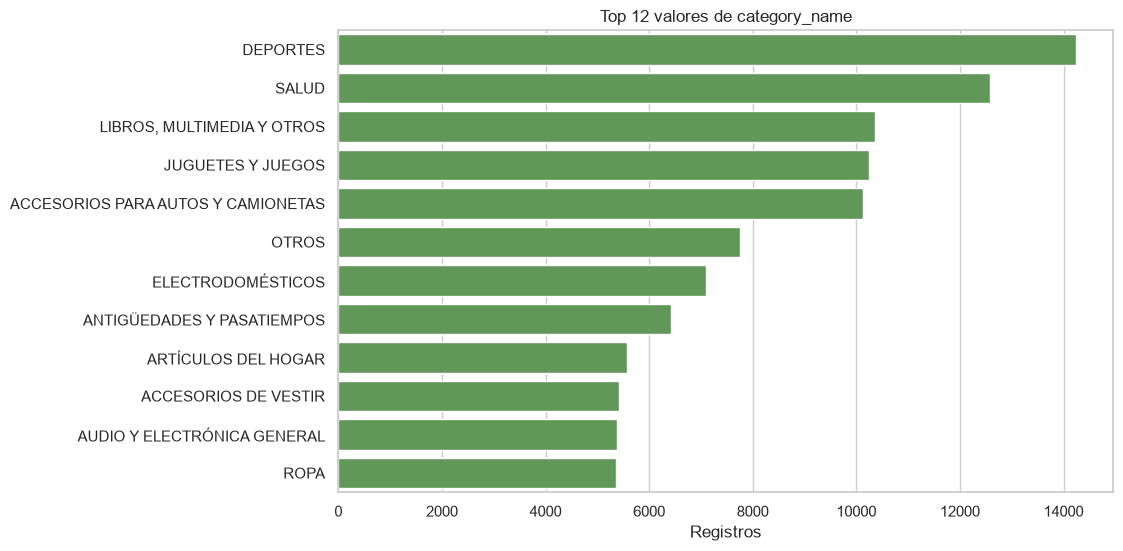

In [7]:
fig1, _ = plot_numeric_distribution(df_final, 'price', log_scale=True)
# Bins en espacio log → distribución legible: mayoría entre $10 y $10.000 MXN.

fig2, _ = plot_numeric_distribution(sf, 'items_count')
# Cola larga: mayoría tiene 1-5 ítems → justifica log1p en el pipeline.

fig3, _ = plot_top_categories(df_final, 'category_name', top_n=12)

## 6. El viaje del clustering — 3 iteraciones

- **Iteración 1 — Baseline:** `StandardScaler` sobre precio bruto con outlier de $4,77B → silueta **0,62 engañosa** (inflada por cluster de artefacto).
- **Iteración 2A** (`log1p` + `StandardScaler`): reveló cluster artificial por imputar con medianas de categorías contaminadas → el orden del pipeline era el bug.
- **Iteración 2B** (p99 + `RobustScaler`): p99=$29.999 eliminó gama alta → **99,51% en un cluster** (inútil).
- **Iteración 3 — Final:** orden correcto + `log1p` + `RobustScaler` + `pct_ds` → silueta honesta **0,2189**.

In [8]:
std_k5 = evaluate_kmeans_range(sf, k_values=[5], feature_columns=LOG_CLUSTER_FEATURES, scaler='standard')
rob_k5 = evaluate_kmeans_range(sf, k_values=[5], feature_columns=LOG_CLUSTER_FEATURES, scaler='robust')

pd.concat([
    std_k5.assign(escalador='log1p + StandardScaler (Iteración 2A)'),
    rob_k5.assign(escalador='log1p + RobustScaler  (Final)'),
], ignore_index=True)[['escalador','silhouette','davies_bouldin','calinski_harabasz','cluster_max_pct']]

,escalador,silhouette,davies_bouldin,calinski_harabasz,cluster_max_pct
0,log1p + StandardScaler (Iteración 2A),0.1990,1.4041,8069.4,43.8
1,log1p + RobustScaler (Final),0.2327,1.2849,21734.8,43.0


## 7. Selección de K — utilidad comercial > óptimo geométrico

In [9]:
evaluation = evaluate_kmeans_range(sf, k_values=range(2, 9),
                                   feature_columns=LOG_CLUSTER_FEATURES, scaler='robust')
evaluation

,k,inercia,silhouette,davies_bouldin,calinski_harabasz,cluster_max_pct
0,2,455649.0,0.5364,0.8761,30061.0,85.2
1,3,351465.0,0.5392,0.9014,26380.5,81.6
2,4,297109.0,0.2933,1.2866,23641.1,56.9
3,5,261450.0,0.2327,1.2849,21734.8,43.0
4,6,232013.0,0.2231,1.2325,20774.0,42.8
5,7,211365.0,0.2185,1.2748,19759.8,36.7
6,8,195442.0,0.2209,1.2510,18857.8,34.2


**K=2:** silueta máxima pero **85,2%** en un grupo → no segmenta.
**K=5:** cluster mayor cae a **43,0%**, aparecen los drop-shippers. Decisión de **utilidad comercial**, no solo matemática.

## 8. Modelo final K=5 y métricas

In [10]:
CLUSTER_NAMES = {
    0: 'Descuentos Activos — Mix FBM/XD',
    1: 'Power Sellers Multi-Categoría',
    2: 'Masa Básica — Primera Publicación',
    3: 'FBM Discount Players',
    4: 'Vendedores Activos — Catálogo en Crecimiento',
}

sf, metrics, pipeline, feats = fit_final_kmeans(
    sf, n_clusters=5, feature_columns=LOG_CLUSTER_FEATURES, scaler='robust')

print(f"Silhouette:        {metrics['silhouette']:.4f}")
print(f"Davies-Bouldin:    {metrics['davies_bouldin']:.4f}")
print(f"Calinski-Harabász: {metrics['calinski_harabasz']:,.0f}\n")

sf.groupby('cluster').agg(
    sellers=('seller_nickname', 'nunique'),
    sil_media=('sil_sample', 'mean'),
    pct_bien=('sil_sample', lambda x: round((x > 0).mean() * 100, 1)),
).round(3).assign(segmento=lambda d: d.index.map(CLUSTER_NAMES))

Silhouette:        0.2327
Davies-Bouldin:    1.2849
Calinski-Harabász: 21,735



,sellers,sil_media,pct_bien,segmento
cluster,,,,
0,5556,0.200,90.2,Descuentos Activos — Mix FBM/XD
1,1505,0.244,85.0,Power Sellers Multi-Categoría
2,20003,0.330,100.0,Masa Básica — Primera Publicación
3,3288,0.394,100.0,FBM Discount Players
4,16172,0.090,75.2,Vendedores Activos — Catálogo en Crecimiento


## 9. Perfiles de los 5 segmentos

,segmento,median_price,items_count,pct_fbm,pct_xd,pct_ds,seller_reputation_score,pct_items_with_discount,sellers,pct
cluster,,,,,,,,,,
0,Descuentos Activos — Mix FBM/XD,1023.01,5.09,0.39,0.49,0.09,7.35,0.84,5556,11.9
1,Power Sellers Multi-Categoría,841.53,30.70,0.14,0.46,0.34,7.65,0.38,1505,3.2
2,Masa Básica — Primera Publicación,8403.77,1.42,0.03,0.68,0.16,4.55,0.03,20003,43.0
3,FBM Discount Players,719.37,2.72,0.79,0.17,0.02,7.86,0.93,3288,7.1
4,Vendedores Activos — Catálogo en Crecimiento,607.23,4.54,0.10,0.70,0.15,6.32,0.17,16172,34.8


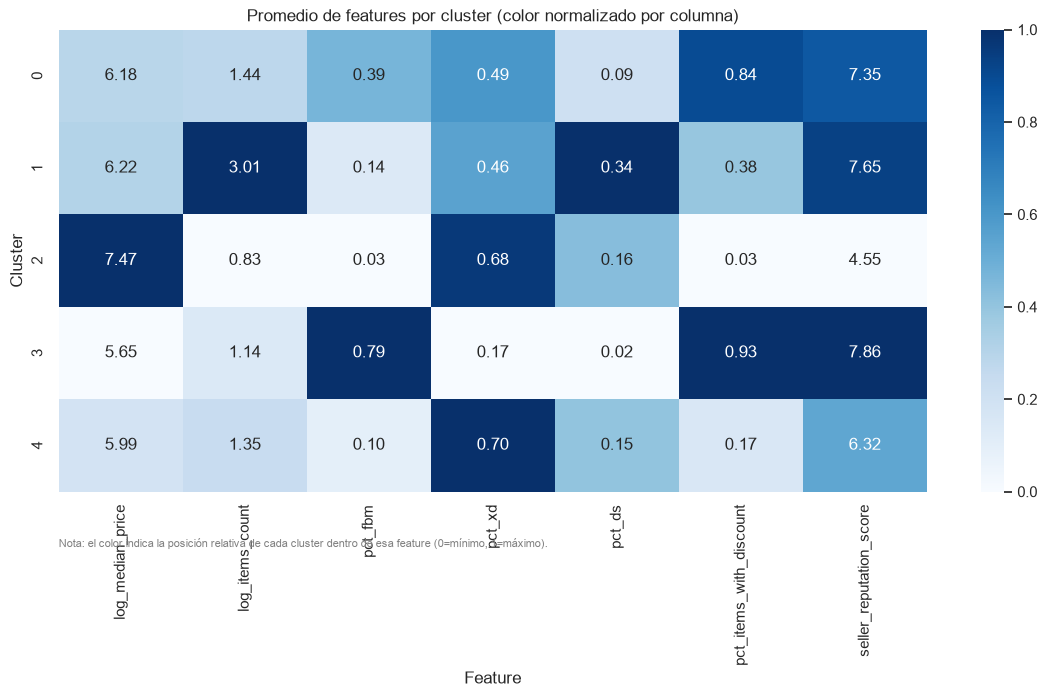

In [14]:
cols = ['median_price','items_count','pct_fbm','pct_xd','pct_ds',
        'seller_reputation_score','pct_items_with_discount']
profile = sf.groupby('cluster')[cols].mean().round(2)
profile.insert(0, 'segmento', profile.index.map(CLUSTER_NAMES))
profile['sellers'] = sf.groupby('cluster').size()
profile['pct'] = (profile['sellers'] / profile['sellers'].sum() * 100).round(1)
display(profile)

fig, _ = plot_cluster_feature_means(
    sf,
    features=['log_median_price','log_items_count','pct_fbm','pct_xd','pct_ds',
              'pct_items_with_discount','seller_reputation_score'],
    normalize_cols=True)

| Cluster | Segmento | % | Rasgo |
|---|---|---|---|
| C2 | Masa Básica — Primera Publicación | 43,0% | 1-2 ítems, XD, sin descuentos |
| C4 | Vendedores Activos — Catálogo en Crecimiento | 34,8% | 4-5 ítems, rep. media, 96% ítems nuevos |
| C0 | Descuentos Activos — Mix FBM/XD | 11,9% | 84% descuento, FBM 39% + XD 49% |
| C3 | FBM Discount Players | 7,1% | FBM 79% + descuentos agresivos |
| C1 | Power Sellers Multi-Categoría | 3,2% | 30 ítems, DS 34%, alto GMV |



## 10. Evaluación de calidad y utilidad

1. ¿≥2 features distinguen cada cluster? ✅
2. ¿Son accionables (herramienta distinta por segmento)? ✅
3. ¿Tamaños útiles? ✅ (C3=846 es chico pero alto GMV)
4. ¿Tienen sentido de mercado? ✅ (reconocibles en cualquier marketplace LATAM)

## 11. Estrategias comerciales

| Segmento | Prioridad | Acción |
|---|---|---|
| C1 Power Sellers | ★★★★★ | AM dedicado; migrar DS→FBM |
| C3 FBM Discount | ★★★★★ | MercadoLíder acelerado; herramienta pricing dinámico |
| C0 Descuentos Activos | ★★★★☆ | Alerta de margen si descuento >40%; acceso MercadoLíder |
| C4 Vendedores Activos | ★★★☆☆ | Challenge de catálogo; incentivo FBM subsidiado |
| C2 Masa Básica | ★★☆☆☆ | Educación automatizada; sub-segmentar por actividad |



## 12. GenAI — la decisión metodológica clave

**Descartado:** embeddings de títulos → agrupan por categoría de producto, no por comportamiento de negocio.

**Adoptado:** K-Means numérico → centroides → JSON → LLM como **capa interpretativa**.

In [12]:
def build_cluster_prompt(summary_df, cluster_names):
    # Centroides a JSON estructurado para el LLM.
    payload = []
    for _, row in summary_df.iterrows():
        cid = int(row['cluster'])
        payload.append({
            'cluster_id': cid, 'hint': cluster_names.get(cid, ''),
            'sellers': int(row['sellers']),
            'share_pct': float(row['seller_share_pct']),
            'avg_log_median_price': round(float(row.get('avg_log_median_price', 0)), 3),
            'avg_pct_fbm': round(float(row.get('avg_pct_fbm', 0)), 3),
            'avg_pct_ds': round(float(row.get('avg_pct_ds', 0)), 3),
            'avg_reputation': round(float(row.get('avg_seller_reputation_score', 0)), 2),
            'avg_pct_discount': round(float(row.get('avg_pct_items_with_discount', 0)), 3),
        })
    system = ('Sos un analista comercial de MELI. Para cada cluster devolvé '
              'segment_name, profile_description, 2 commercial_actions y churn_risk.')
    user = 'Centroides:\n' + json.dumps(payload, ensure_ascii=False, indent=2)
    return system, user

summary = summarize_clusters(sf)
_, user_prompt = build_cluster_prompt(summary, CLUSTER_NAMES)
print(user_prompt[:600], '\n...')

# Llamada real: from anthropic import Anthropic; client.messages.create(...)

MOCK = {'segments': [
    {'cluster_id': 2, 'segment_name': 'FBM Discount Players',
     'commercial_actions': ['MercadoLíder acelerado', 'Alerta margen >40%'], 'churn_risk': 'medio'},
    {'cluster_id': 4, 'segment_name': 'Alto Ticket Sin Historial',
     'commercial_actions': ['Programa Primera Venta', 'Badge Verificado'], 'churn_risk': 'alto'},
    {'cluster_id': 3, 'segment_name': 'Power Sellers',
     'commercial_actions': ['AM dedicado', 'Migrar DS→FBM'], 'churn_risk': 'bajo'},
    {'cluster_id': 0, 'segment_name': 'Vendedores Activos',
     'commercial_actions': ['Trial FBM', 'Challenge catálogo'], 'churn_risk': 'bajo-medio'},
    {'cluster_id': 1, 'segment_name': 'Masa Básica',
     'commercial_actions': ['5 emails/30 días', 'Sub-segmentar por actividad'], 'churn_risk': 'alto'},
]}
print('\nRespuesta LLM (mock):')
print(json.dumps(MOCK, ensure_ascii=False, indent=2))

Centroides:
[
  {
    "cluster_id": 2,
    "hint": "Masa Básica — Primera Publicación",
    "sellers": 20003,
    "share_pct": 43.0,
    "avg_log_median_price": 7.469,
    "avg_pct_fbm": 0.031,
    "avg_pct_ds": 0.163,
    "avg_reputation": 4.55,
    "avg_pct_discount": 0.026
  },
  {
    "cluster_id": 4,
    "hint": "Vendedores Activos — Catálogo en Crecimiento",
    "sellers": 16172,
    "share_pct": 34.76,
    "avg_log_median_price": 5.993,
    "avg_pct_fbm": 0.103,
    "avg_pct_ds": 0.154,
    "avg_reputation": 6.32,
    "avg_pct_discount": 0.167
  },
  {
    "cluster_id": 0,
    "hint": " 
...

Respuesta LLM (mock):
{
  "segments": [
    {
      "cluster_id": 2,
      "segment_name": "FBM Discount Players",
      "commercial_actions": [
        "MercadoLíder acelerado",
        "Alerta margen >40%"
      ],
      "churn_risk": "medio"
    },
    {
      "cluster_id": 4,
      "segment_name": "Alto Ticket Sin Historial",
      "commercial_actions": [
        "Programa Primera Venta

## 13. Escalabilidad — BigQuery + DataFlow

| Estrategia | Particiones/10 años | GB/partición | ¿Cerca del límite 4.000? |
|---|---|---|---|
| Diaria | 3.650 | 6,85 GB | Sí ⚠️ |
| Semanal | 520 | ~48 GB | No ✅ |
| **Mensual** | **120** | **~208 GB** | **No ✅** |

> **Herramienta elegida: DataFlow** (la plataforma interna de MELI). La IA propuso dbt + Airflow — fue reemplazado. Ver `INFORME_TECNICO.md` §2.5 para el DDL, el SQL completo y las recomendaciones de performance.

**Ahorro incremental:** full refresh $625/día vs DataFlow incremental $1,70/día (~$227K/año)  
**Mecanismo:** variable `DATE_FROM = <JOB:LAST_START_OK>` → procesa solo los datos nuevos.

In [13]:
# SQL del job DataFlow (ilustrativo — ejecutar en DataFlow, no en local)
dataflow_sql = '''
INSERT INTO TBL.seller_daily_features
SELECT tim_day, seller_nickname,
  COUNT(*)                                                   AS items_count,
  AVG(price)                                                 AS avg_price,
  APPROX_QUANTILES(price, 100)[OFFSET(50)]                  AS median_price,
  COUNT(DISTINCT category_id)                               AS categories_count,
  AVG(CASE WHEN logistic_type = 'FBM'  THEN 1 ELSE 0 END)  AS pct_fbm,
  AVG(CASE WHEN logistic_type = 'XD'   THEN 1 ELSE 0 END)  AS pct_xd,
  AVG(CASE WHEN logistic_type = 'DS'   THEN 1 ELSE 0 END)  AS pct_ds,
  AVG(CASE WHEN logistic_type = 'FLEX' THEN 1 ELSE 0 END)  AS pct_flex,
  AVG(CASE WHEN regular_price > price
      THEN (regular_price - price) / regular_price END)     AS avg_discount_pct
FROM TBL.items_snapshot_raw
WHERE tim_day >= '${DATE_FROM}'   -- <JOB:LAST_START_OK>
GROUP BY tim_day, seller_nickname;
'''
print('Job DataFlow: seller_daily_features')
print('Variable: DATE_FROM = <JOB:LAST_START_OK>')
print('Scheduler: daily 06:00  |  desa -> prod')
print(dataflow_sql)

Job DataFlow: seller_daily_features
Variable: DATE_FROM = <JOB:LAST_START_OK>
Scheduler: daily 06:00  |  desa -> prod

INSERT INTO TBL.seller_daily_features
SELECT tim_day, seller_nickname,
  COUNT(*)                                                   AS items_count,
  AVG(price)                                                 AS avg_price,
  APPROX_QUANTILES(price, 100)[OFFSET(50)]                  AS median_price,
  COUNT(DISTINCT category_id)                               AS categories_count,
  AVG(CASE WHEN logistic_type = 'FBM'  THEN 1 ELSE 0 END)  AS pct_fbm,
  AVG(CASE WHEN logistic_type = 'XD'   THEN 1 ELSE 0 END)  AS pct_xd,
  AVG(CASE WHEN logistic_type = 'DS'   THEN 1 ELSE 0 END)  AS pct_ds,
  AVG(CASE WHEN logistic_type = 'FLEX' THEN 1 ELSE 0 END)  AS pct_flex,
  AVG(CASE WHEN regular_price > price
      THEN (regular_price - price) / regular_price END)     AS avg_discount_pct
FROM TBL.items_snapshot_raw
WHERE tim_day >= '${DATE_FROM}'   -- <JOB:LAST_START_OK>
GROUP BY tim_d

## 14. Conclusiones y próximos pasos

La calidad del clustering dependió del **orden del pipeline**, no del algoritmo. El umbral de dominio ($1M MXN), la imputación por categoría, `has_reputation`, `pct_ds` y `RobustScaler` + `log1p` produjeron 5 segmentos honestos (silueta 0,23).

**Próximos pasos:**

1. Scoring en Vertex AI con re-entrenamiento mensual.
2. Enriquecer con GMV y cancelaciones para validar la priorización.
3. Activar GenAI real (`pip install anthropic` + `ANTHROPIC_API_KEY`).
4. Implementar el job en DataFlow con `DATE_FROM = <JOB:LAST_START_OK>`.
5. Cerrar el loop con el CRM y medir el uplift por estrategia.
6. Reutilizar en otros sites:
   - `/generar-analisis --site MLB --data mlb.csv`
   - `/generate-html-report --output report_mlb.html`

> [`INFORME_TECNICO.md`](INFORME_TECNICO.md) · `report_mlm.html`